# VarDyn CSWM JET run
Run the CSW internal-tide configuration for the JET BM-IT OSSE data with the current VarDyn API.

Select the GPU device that JAX/CUDA should use for this notebook session.

In [1]:
import os
NUM_GPU = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = NUM_GPU

Point the notebook to the CSWM configuration file.

In [2]:
path_config = 'config_VarDyn-CSWM-JET.py'

Add the local VarDyn mapping package to `sys.path` so the `src` modules can be imported from the notebook.

In [3]:
import sys
sys.path.append('/home/flo/VarDyn/mapping')

## Load Configuration

Load and merge the experiment configuration with the VarDyn defaults.

In [4]:
from src import exp
config = exp.Exp(path_config)

name_experiment: VarDyn-CSWM-JET
name_exp_save: VarDyn-CSWM-JET
path_save: ./outputs/VarDyn-CSWM-JET
tmp_DA_path: ./scratch/VarDyn-CSWM-JET
init_date: 2010-05-01 00:00:00
final_date: 2010-07-01 00:00:00
assimilation_time_step: 1:00:00
saveoutput_time_step: 3:00:00
flag_plot: 1
write_obs: True
path_obs: ./obs
compute_obs: True
saveoutputs: True
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None



Build the model grid and state object, then display the land/sea mask as a quick geometry check.

In [5]:
from src import state
State = state.State(config)

super: GRID_FROM_FILE
path_init_grid: /data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc
name_init_lon: lon
name_init_lat: lat
subsampling: None
name_init_mask: None
name_var_mask: {'lon': '', 'lat': '', 'var': ''}

No mask provided


Text(0.5, 1.0, 'CSWM grid mask')

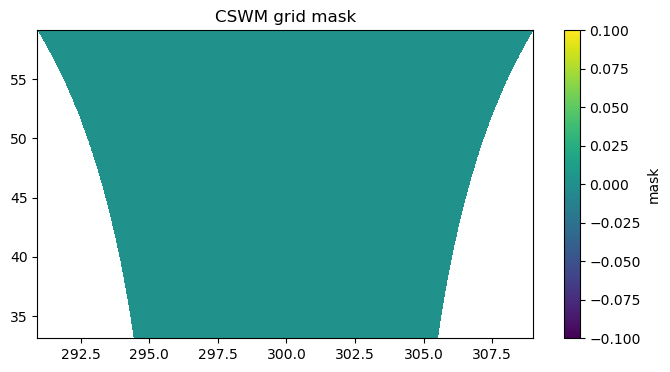

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.pcolormesh(State.lon, State.lat, State.mask)
plt.colorbar(label='mask')
plt.title('CSWM grid mask')

Instantiate the CSW internal-tide model. Reading auxiliary mode and balanced-motion fields can take a few minutes.

super: MOD_CSW1L
name_var: {'U': 'u_it', 'V': 'v_it', 'SSH': 'ssh_it'}
name_params: ['He_mean', 'hbc', 'alpha']
name_init_var: {}
dir_model: None
var_to_save: None
g: 9.81
dtmodel: 300
cfl: 0.3
time_scheme: rk4
path_mdt: /data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc
name_var_mdt: {'lon': 'lon', 'lat': 'lat', 'var': 'mdt'}
c0: 2.7
filec_aux: /data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc
name_var_c: {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}
constant_He: False
H: 4000
file_H_aux: None
name_var_H: {'lon': '', 'lat': '', 'var': ''}
w_waves: [0.0001454441043328608]
Ntheta: 1
flag_coupling_from_bm: True
path_vertical_modes: /data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc
path_interaction_terms: None
name_var_interaction_terms: {'lon': '', 'lat': '', 'U11_u': '', 'U11_p': '', 'U11_z': '', 'dc2': ''}
path_bm: /data1/data/models/JET_BM-IT/full_resolution/wp6_surf_data_ref_coarse2.nc
name_var_bm: {'ti

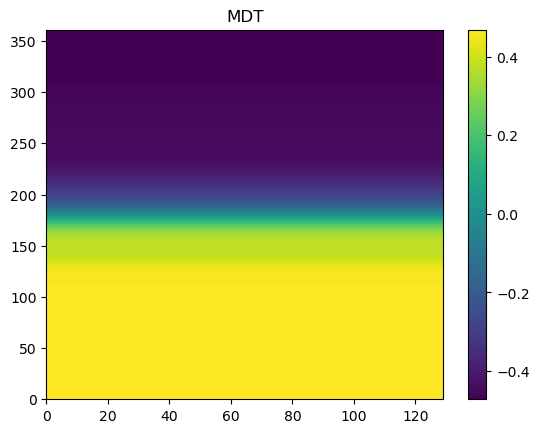

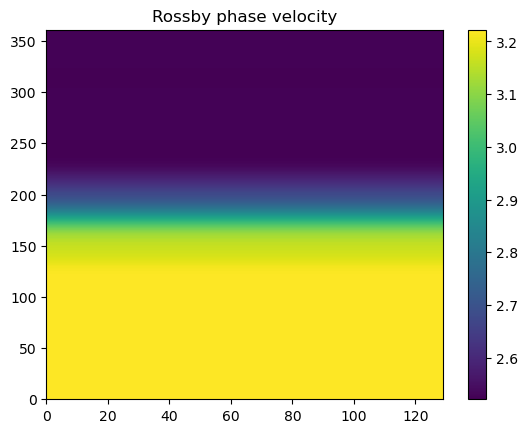

CFL condition for max(c)= 3.222325936000397 m/s and grid spacing ~ 7985.977235250549 m: dt<= 743.498087455691 s
Model time-step 720


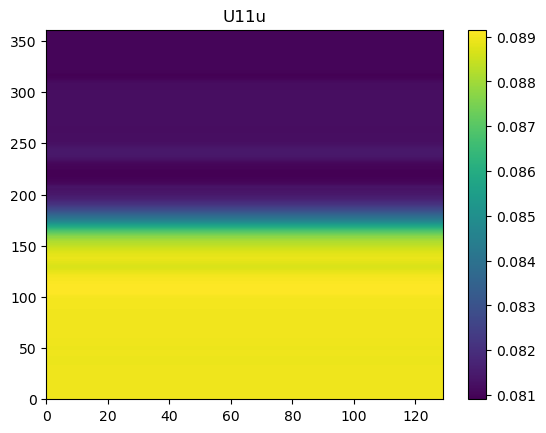

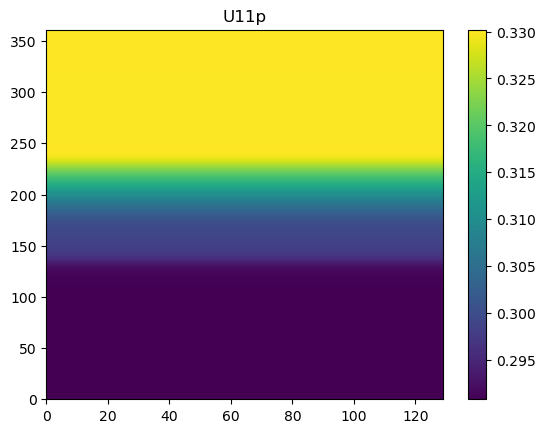

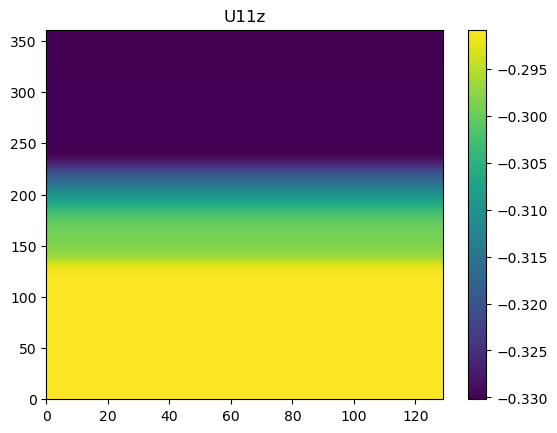

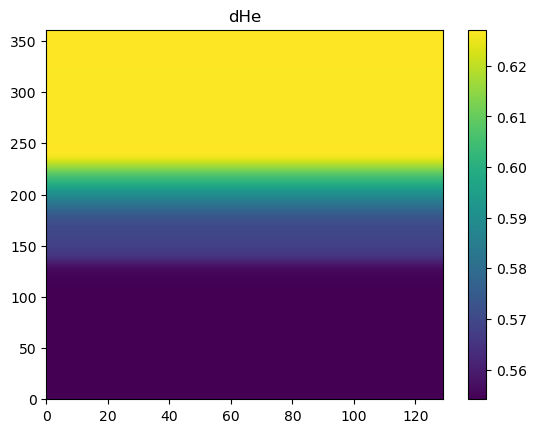

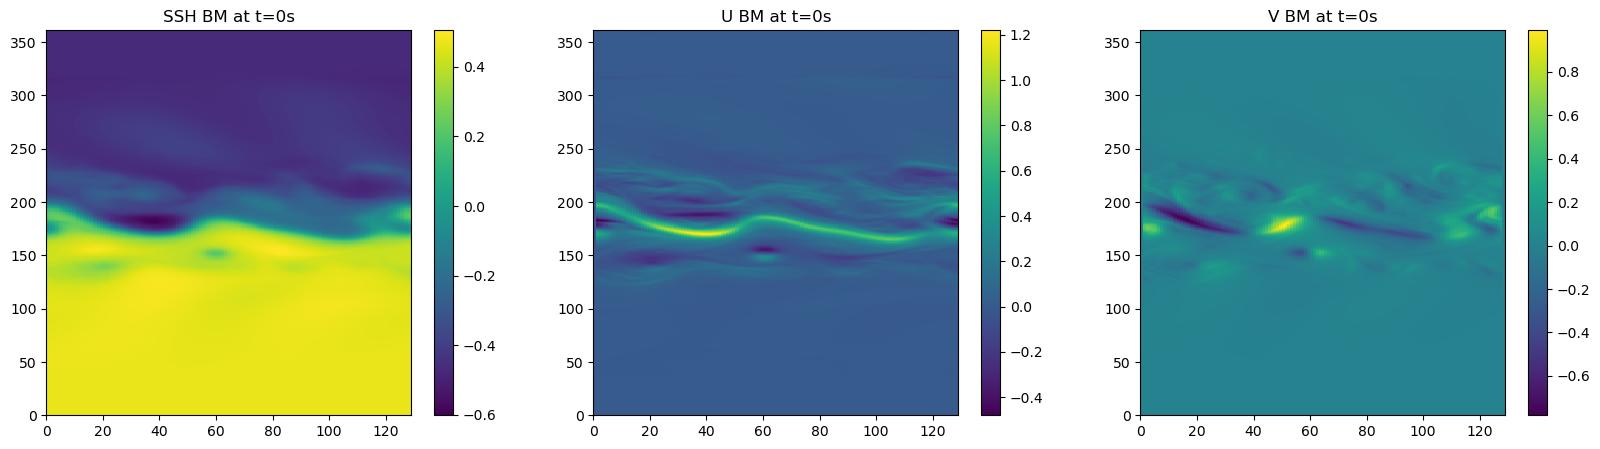

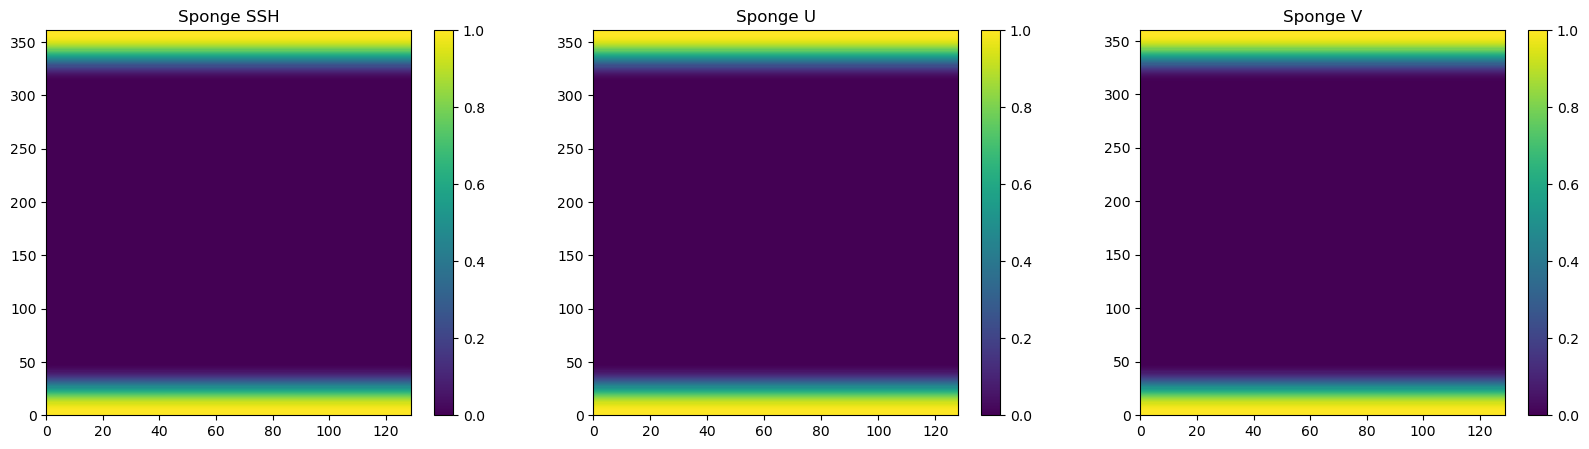

/home/flo/VarDyn/mapping/src/mod.py:1999: UserWarning: CSWm: Ntheta=1 is below the boundary Nyquist minimum Ntheta_min=27 (lambda_min=108.9 km, L_bdy=2886.2 km). Aliasing in along-boundary wave angle. Consider increasing Ntheta or setting Ntheta=-1 for auto.
  self.swm = model(X=X,


In [7]:
from src import mod
Model = mod.Model(config, State)

Open and preprocess the OSSE SSH observations.

In [8]:
from src import obs
dict_obs = obs.Obs(config, State)

Observation information will be saved in dict_obs_NR_20100501_20100701_291_308_33_59_3600.txt

NR:
super: OBS_L4
path: /data1/data/models/JET_BM-IT/full_resolution/wp6_surf_data_ref_coarse2.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SSH': 'ssh_it'}
name_err: {}
subsampling: 81
sigma_noise: 0.02
offset: None

--> 6 fields selected


Build the L4 observation operator.

In [9]:
from src import obsop
Obsop = obsop.Obsop(config, State, dict_obs, Model)

super: OBSOP_INTERP_L4
name_obs: ['NR']
name_var: SSH
write_op: True
path_save: ./H
compute_op: True
mask_borders: False
interp_method: linear
gradients: False



Construct the reduced basis used as the 4DVar control-vector representation.

In [10]:
from src import basis
Basis = basis.Basis(config, State)

super: BASIS_GAUSS3D
name_mod_var: He_mean
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: False
facns: 2.0
facnlt: 2.0
sigma_D: 1000
sigma_T: 50
sigma_Q: 0.01
fcor: 0.5
normalize_fact: False
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_OFFSET
name_mod_var: alpha
sigma_B: 0.1

super: BASIS_HBC
name_params: ['hbcx', 'hbcy']
facns: 3.5
facnlt: 2.5
time_dependant: False
sigma_B_bc: 0.01
D_bc: 1000
T_bc: 50
Nwaves: 1
Ntheta: 1



## Run 4DVar

super: INV_4DVAR
compute_test: False
freq_it_plot: 10
print_time: False
JAX_mem_fraction: None
path_init_4Dvar: None
restart_4Dvar: False
ftol: 5e-05
gtol: None
convergence_nit: None
maxiter: 50
gradient_max_norm: 1000000.0
max_retries: 5
opt_method: L-BFGS-B
save_minimization: True
path_save_control_vectors: ./controls/VarDyn-CSWM-JET
timestep_checkpoint: 1 day, 0:00:00
sigma_R: None
sigma_B: None
prec: True
path_background: None
anomaly_from_bc: False

process observation operators
Processing observations at date 2010-05-02 12:00:00 for variable SSH...
Processing observations at date 2010-05-12 15:00:00 for variable SSH...


Processing observations at date 2010-05-22 18:00:00 for variable SSH...
Processing observations at date 2010-06-01 21:00:00 for variable SSH...
Processing observations at date 2010-06-12 00:00:00 for variable SSH...
Processing observations at date 2010-06-22 03:00:00 for variable SSH...
--> 67 checkpoints to evaluate the cost function


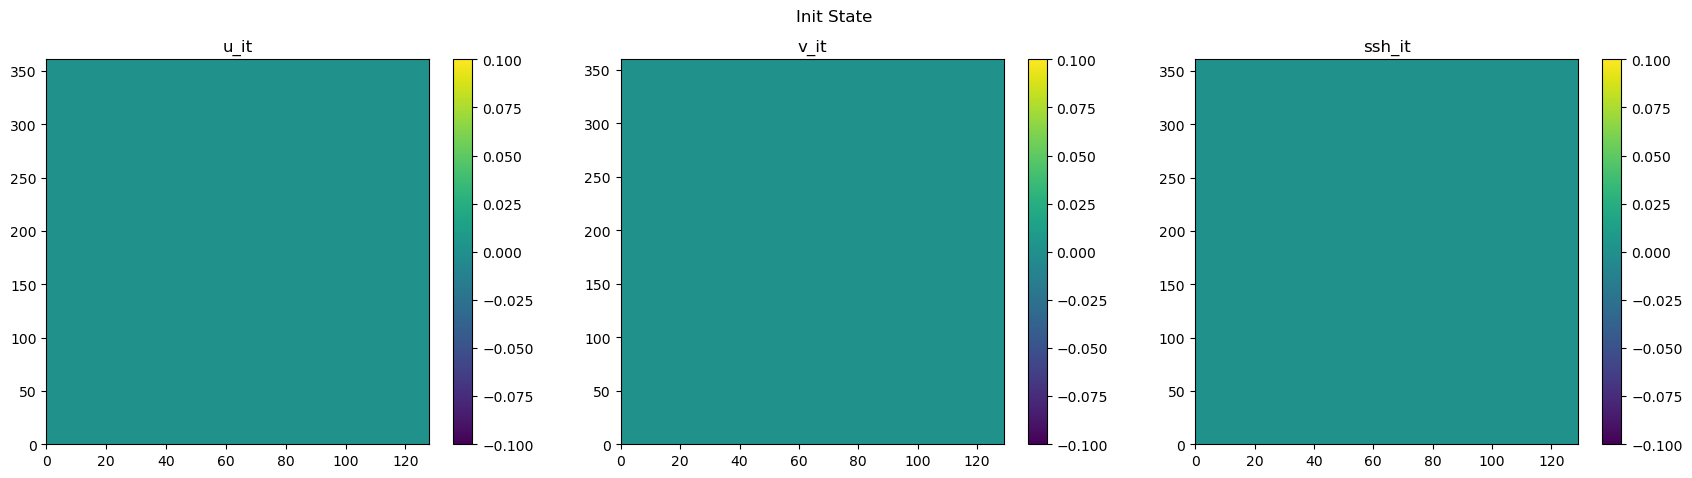

Can't plot parameters
Can't plot parameters


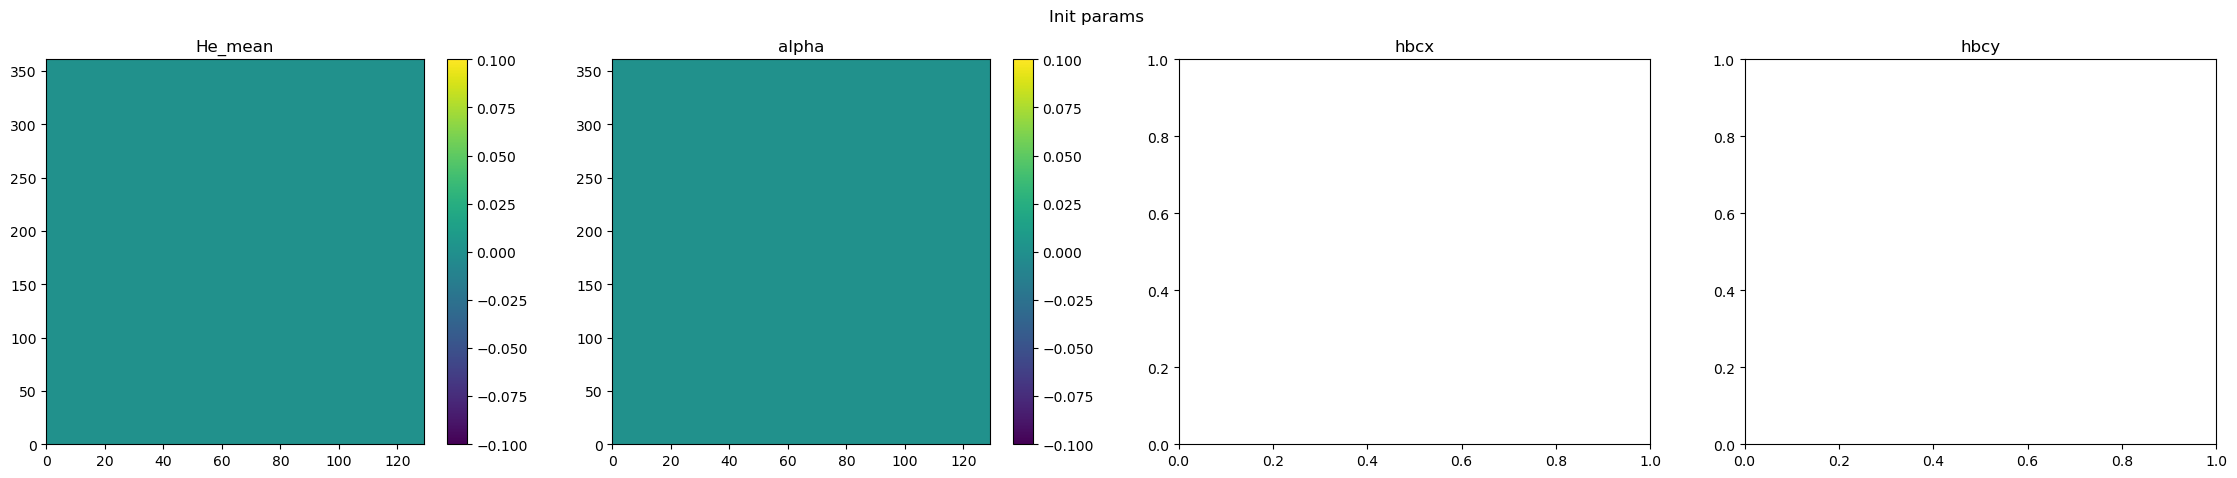

lambda=1.0E+03 nlocs=5.6E+01 tdec=5.0E+01 ntime=5.0E+00 Q=5.0E-03
reduced order: 2887278 --> 280
 reduced factor: 10311
nbcx: 108
nbcy: 168
reduced order: 364560 --> 276
reduced factor: 1320

*** Minimization ***



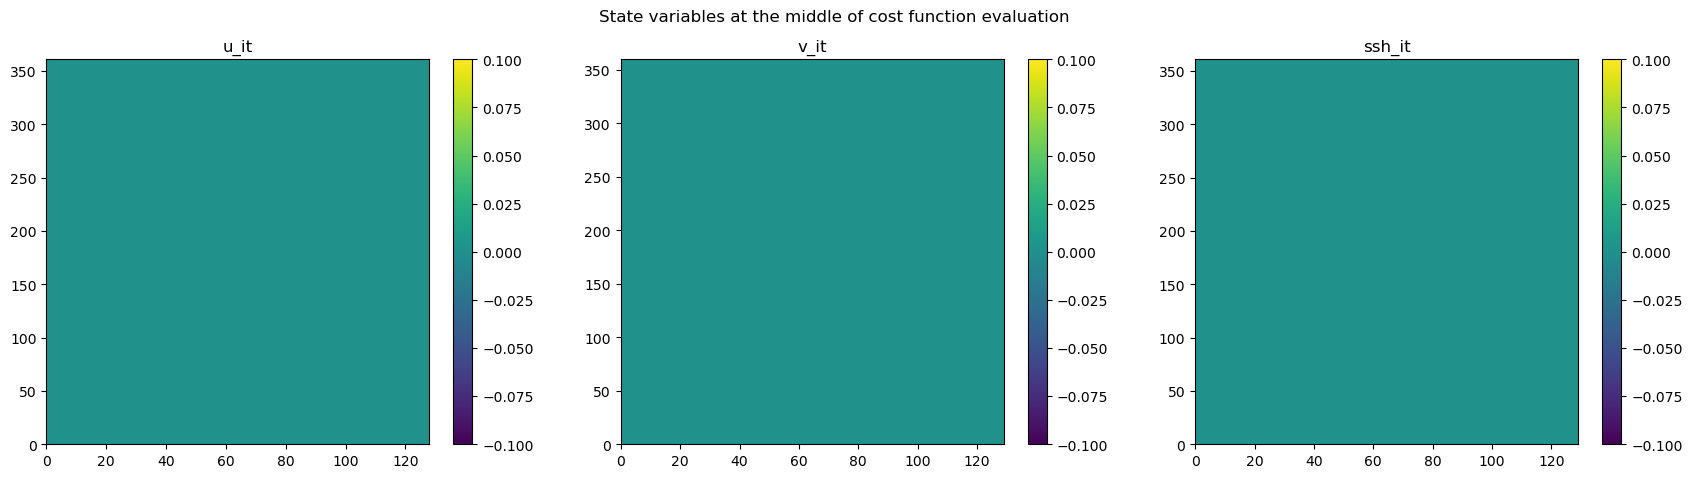

Can't plot parameters
Can't plot parameters


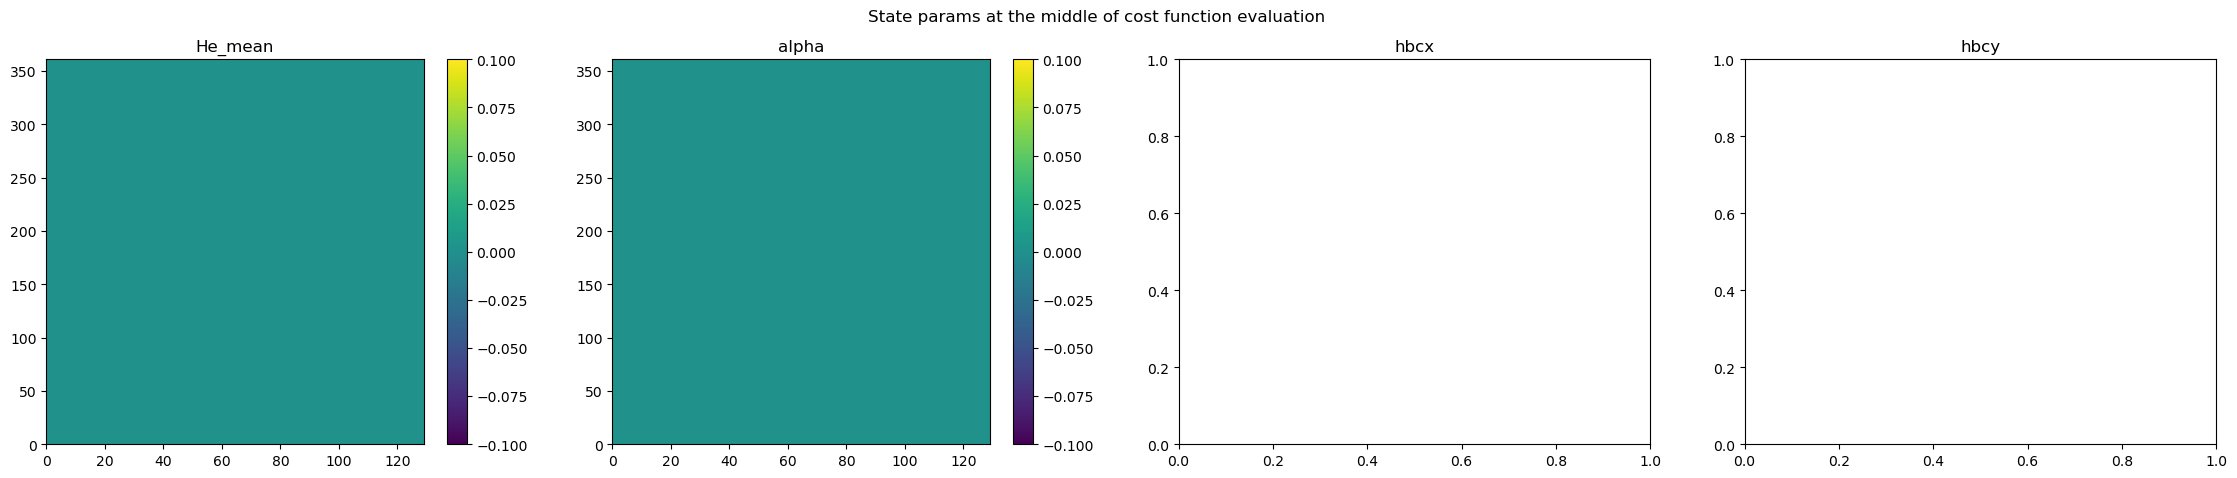

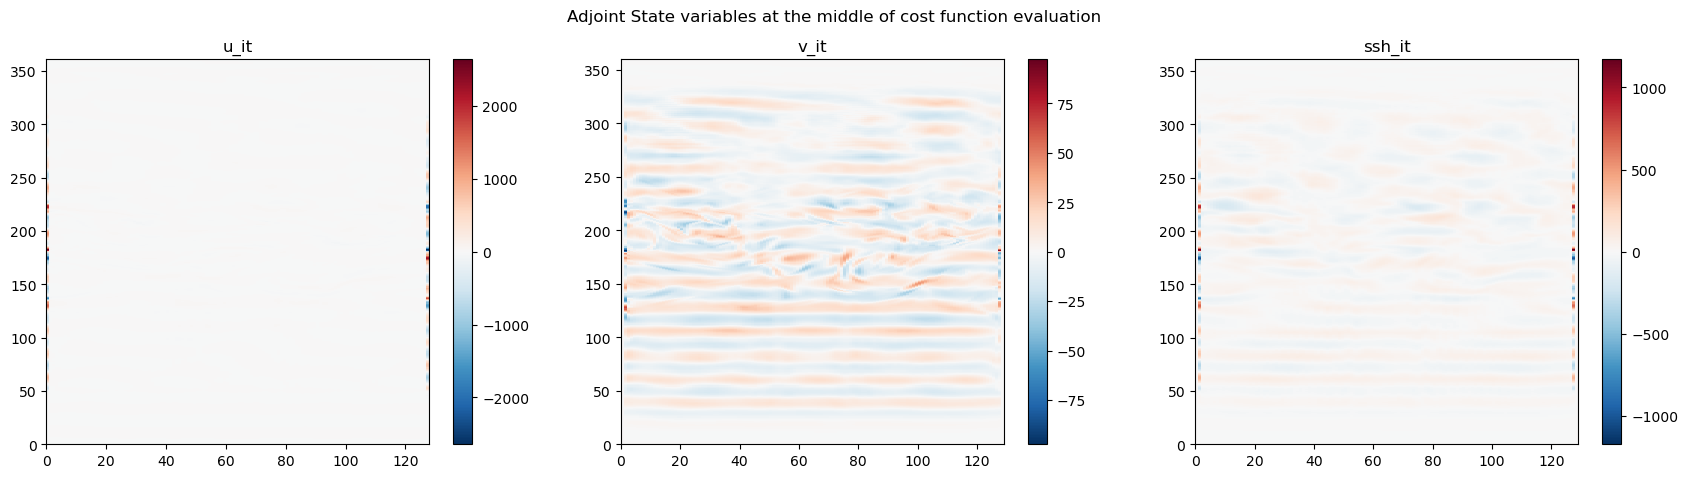

[cost] first evaluation compile+run time: 98.70 seconds
* iteration 1 computed in 1.14E+01 second:, x=0.00E+00, J=1.07E+05, G=1.40E+02, ftol=0.00E+00, gtol=2.07E-09
* iteration 2 computed in 1.16E+01 second:, x=-6.21E-03, J=8.76E+04, G=1.20E+02, ftol=1.78E-01, gtol=1.44E-01
* iteration 3 computed in 9.76E+00 second:, x=-5.24E-02, J=3.22E+04, G=4.73E+01, ftol=6.32E-01, gtol=6.06E-01
* iteration 4 computed in 1.28E+01 second:, x=-5.56E-02, J=3.08E+04, G=3.50E+01, ftol=4.45E-02, gtol=2.59E-01
* iteration 5 computed in 1.37E+01 second:, x=-5.54E-02, J=3.00E+04, G=1.93E+01, ftol=2.80E-02, gtol=4.49E-01
* iteration 6 computed in 1.38E+01 second:, x=-5.76E-02, J=2.96E+04, G=1.43E+01, ftol=1.23E-02, gtol=2.58E-01
* iteration 7 computed in 1.43E+01 second:, x=-6.29E-02, J=2.91E+04, G=1.31E+01, ftol=1.68E-02, gtol=8.49E-02
* iteration 8 computed in 1.57E+01 second:, x=-6.59E-02, J=2.87E+04, G=1.32E+01, ftol=1.19E-02, gtol=5.44E-03
* iteration 9 computed in 1.50E+01 second:, x=-6.99E-02, J=2.83E+

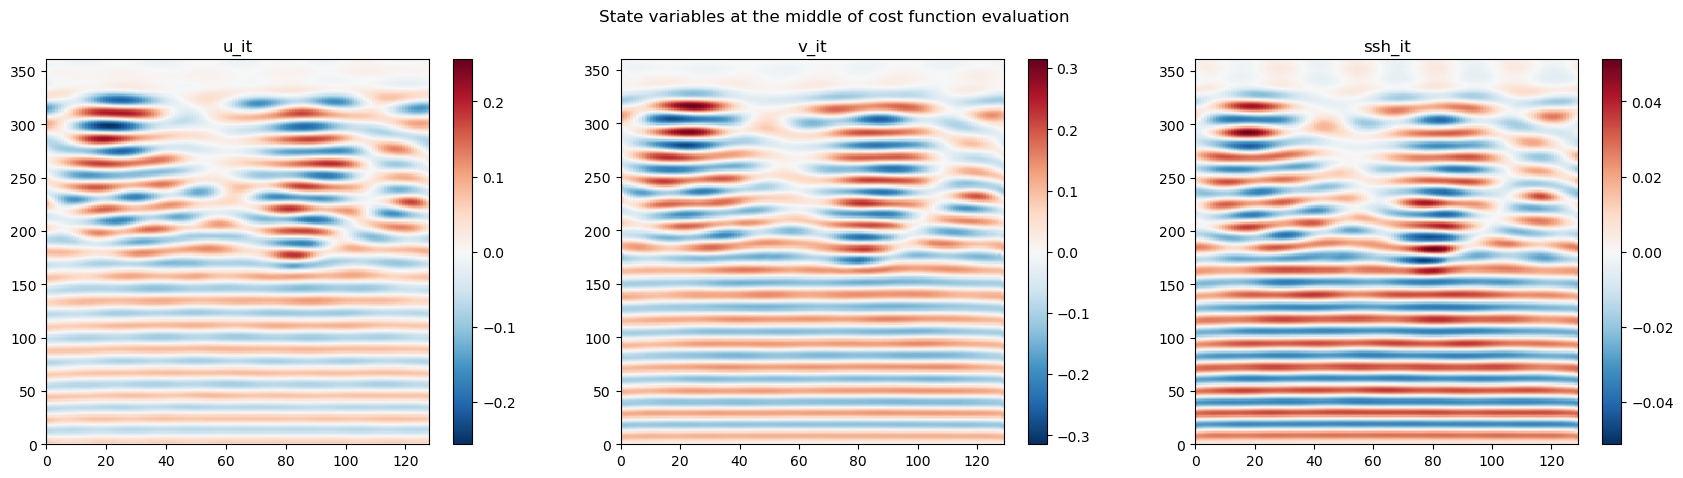

Can't plot parameters
Can't plot parameters


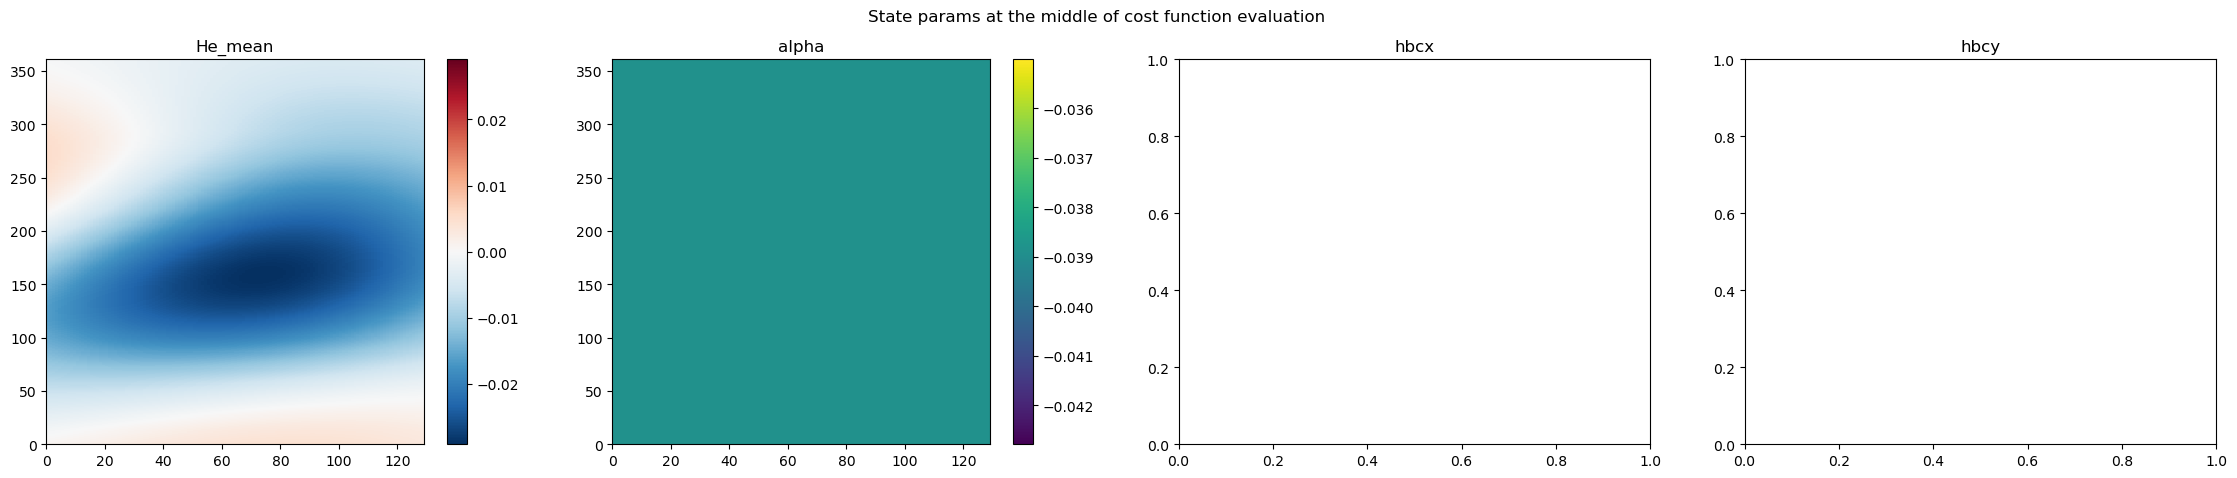

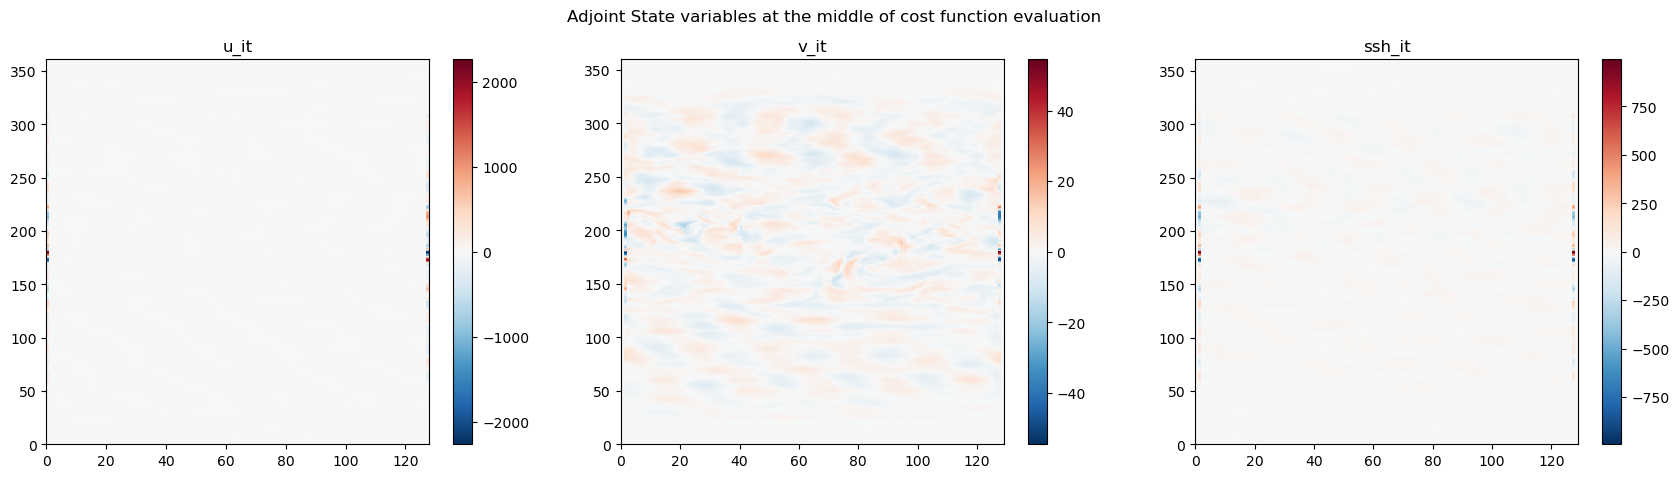

* iteration 10 computed in 1.64E+01 second:, x=-7.61E-02, J=2.76E+04, G=1.55E+01, ftol=2.39E-02, gtol=5.56E-01
* iteration 11 computed in 1.46E+01 second:, x=-7.48E-02, J=2.74E+04, G=1.21E+01, ftol=9.41E-03, gtol=2.23E-01
* iteration 12 computed in 1.61E+01 second:, x=-7.64E-02, J=2.70E+04, G=8.05E+00, ftol=1.24E-02, gtol=3.33E-01
* iteration 13 computed in 1.42E+01 second:, x=-7.84E-02, J=2.68E+04, G=8.60E+00, ftol=6.77E-03, gtol=6.50E-02
* iteration 14 computed in 1.49E+01 second:, x=-8.42E-02, J=2.67E+04, G=1.39E+01, ftol=4.96E-03, gtol=3.83E-01
* iteration 15 computed in 1.49E+01 second:, x=-8.59E-02, J=2.65E+04, G=6.41E+00, ftol=5.83E-03, gtol=5.41E-01
* iteration 16 computed in 1.42E+01 second:, x=-8.65E-02, J=2.65E+04, G=5.51E+00, ftol=1.69E-03, gtol=1.40E-01
* iteration 17 computed in 8.67E+00 second:, x=-8.83E-02, J=2.64E+04, G=4.23E+00, ftol=2.33E-03, gtol=2.32E-01
* iteration 18 computed in 9.61E+00 second:, x=-8.94E-02, J=2.64E+04, G=9.13E+00, ftol=1.20E-05, gtol=5.36E-01
*

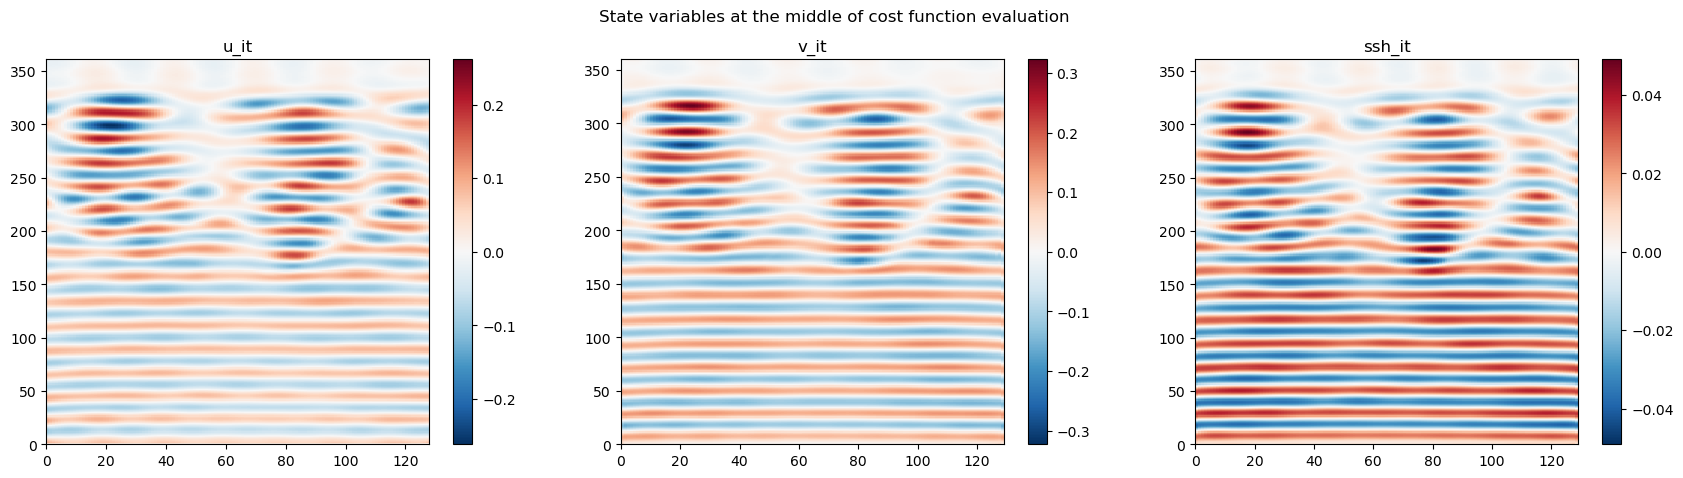

Can't plot parameters
Can't plot parameters


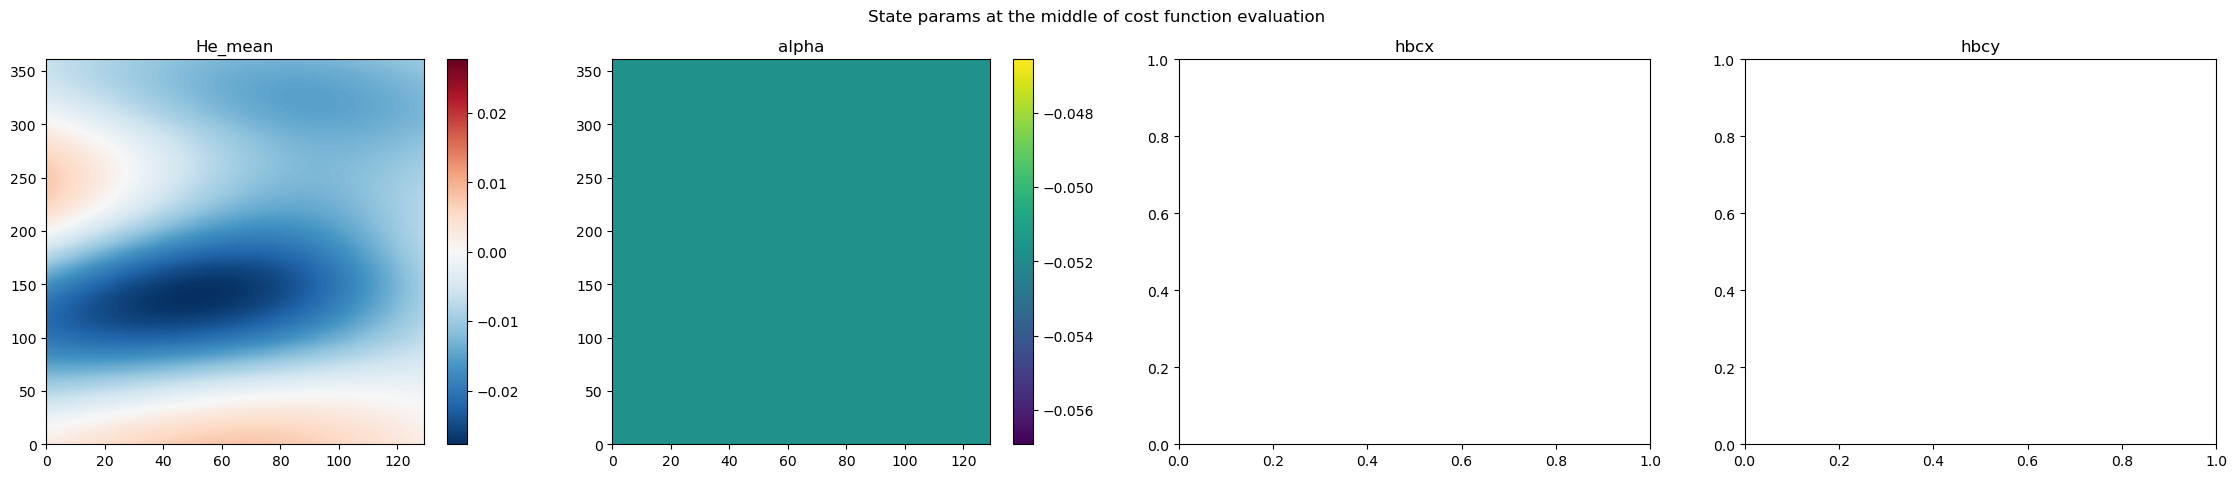

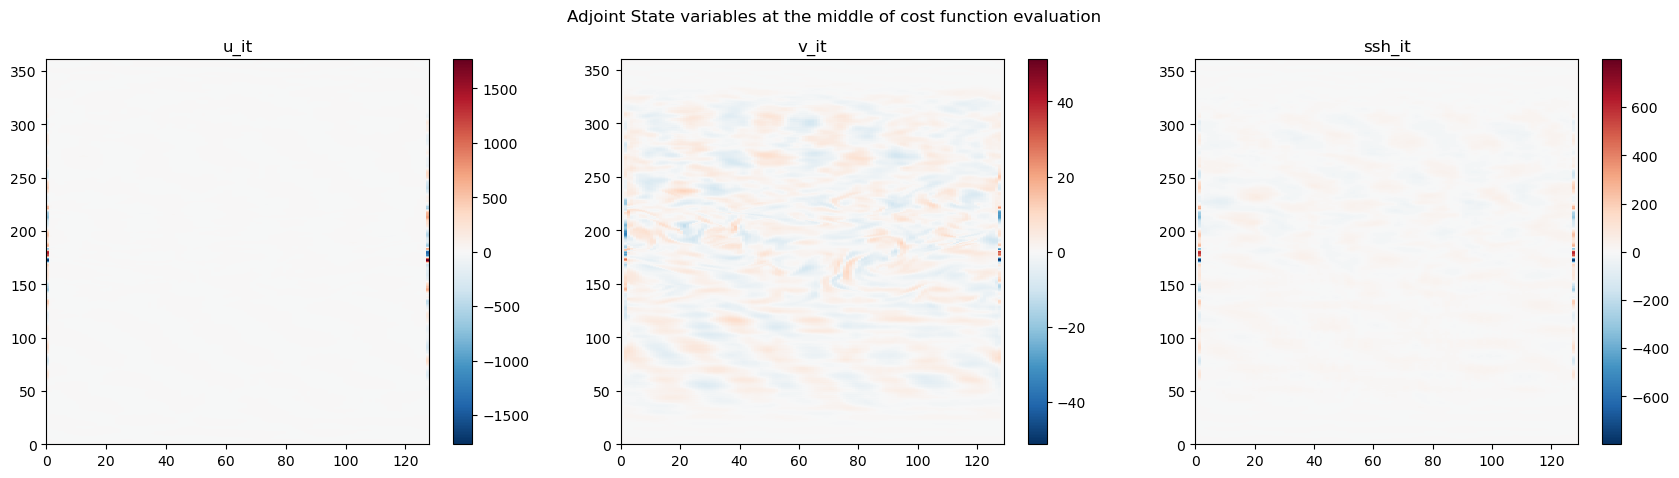

* iteration 20 computed in 1.09E+01 second:, x=-9.03E-02, J=2.64E+04, G=3.74E+00, ftol=1.37E-03, gtol=2.83E-01
* iteration 21 computed in 9.77E+00 second:, x=-9.10E-02, J=2.64E+04, G=3.35E+00, ftol=8.04E-04, gtol=1.04E-01
* iteration 22 computed in 9.34E+00 second:, x=-9.20E-02, J=2.63E+04, G=3.54E+00, ftol=1.10E-03, gtol=5.25E-02
* iteration 23 computed in 9.74E+00 second:, x=-9.36E-02, J=2.63E+04, G=4.29E+00, ftol=6.70E-04, gtol=1.76E-01
* iteration 24 computed in 8.75E+00 second:, x=-9.35E-02, J=2.63E+04, G=3.39E+00, ftol=3.70E-04, gtol=2.10E-01
* iteration 25 computed in 1.12E+01 second:, x=-9.34E-02, J=2.63E+04, G=2.03E+00, ftol=2.57E-04, gtol=4.00E-01
* iteration 26 computed in 9.61E+00 second:, x=-9.35E-02, J=2.63E+04, G=2.31E+00, ftol=2.17E-04, gtol=1.22E-01
* iteration 27 computed in 8.75E+00 second:, x=-9.37E-02, J=2.63E+04, G=3.22E+00, ftol=4.70E-04, gtol=2.81E-01
* iteration 28 computed in 1.00E+01 second:, x=-9.44E-02, J=2.63E+04, G=4.20E+00, ftol=8.81E-04, gtol=2.34E-01
*

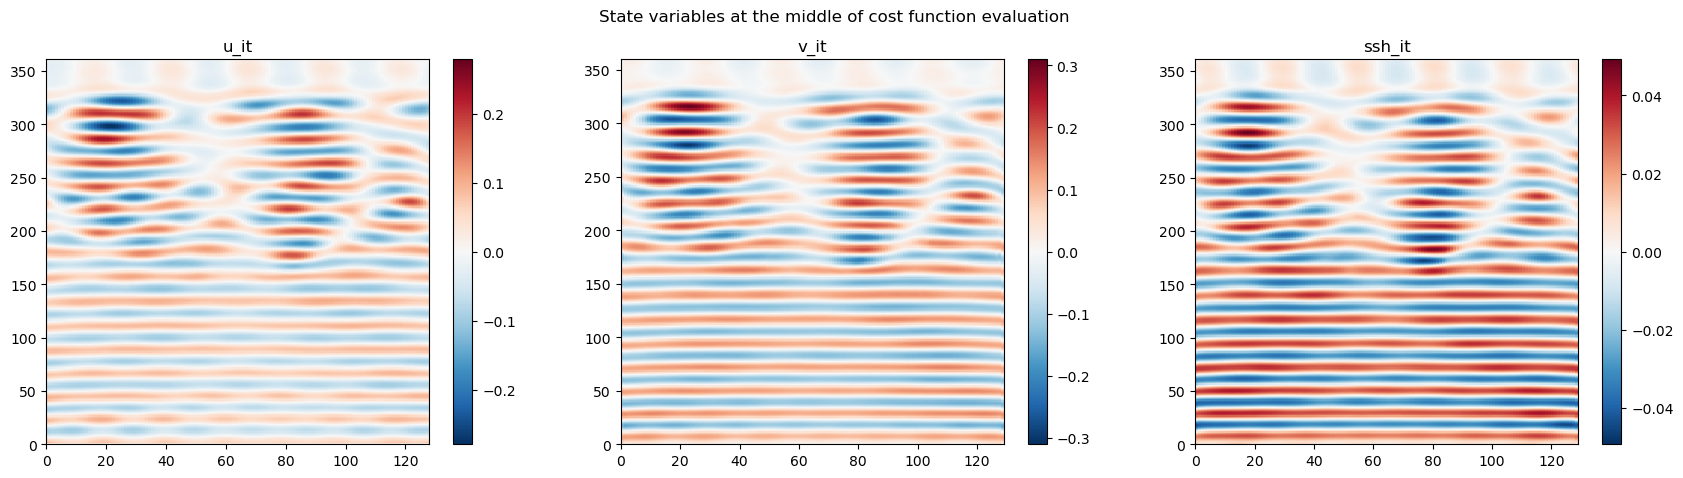

Can't plot parameters
Can't plot parameters


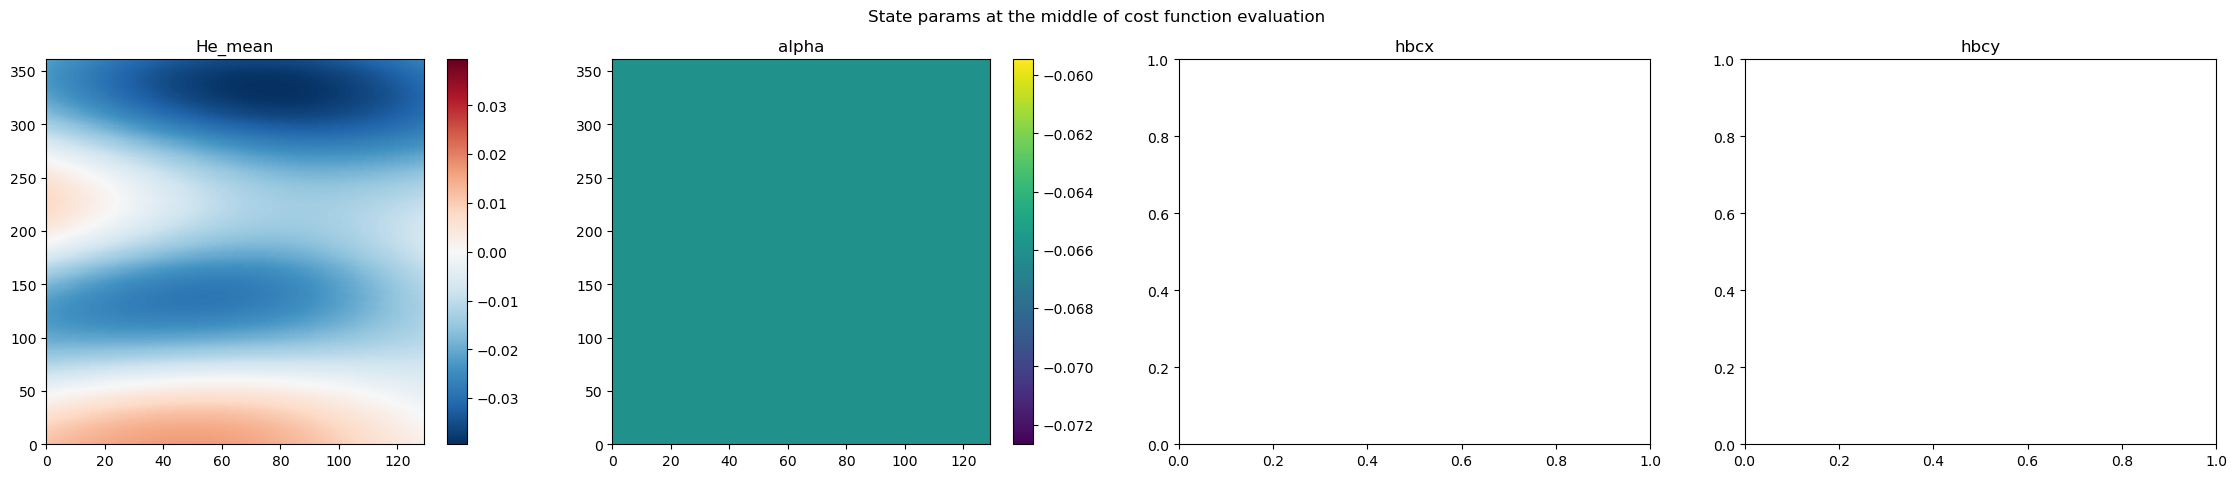

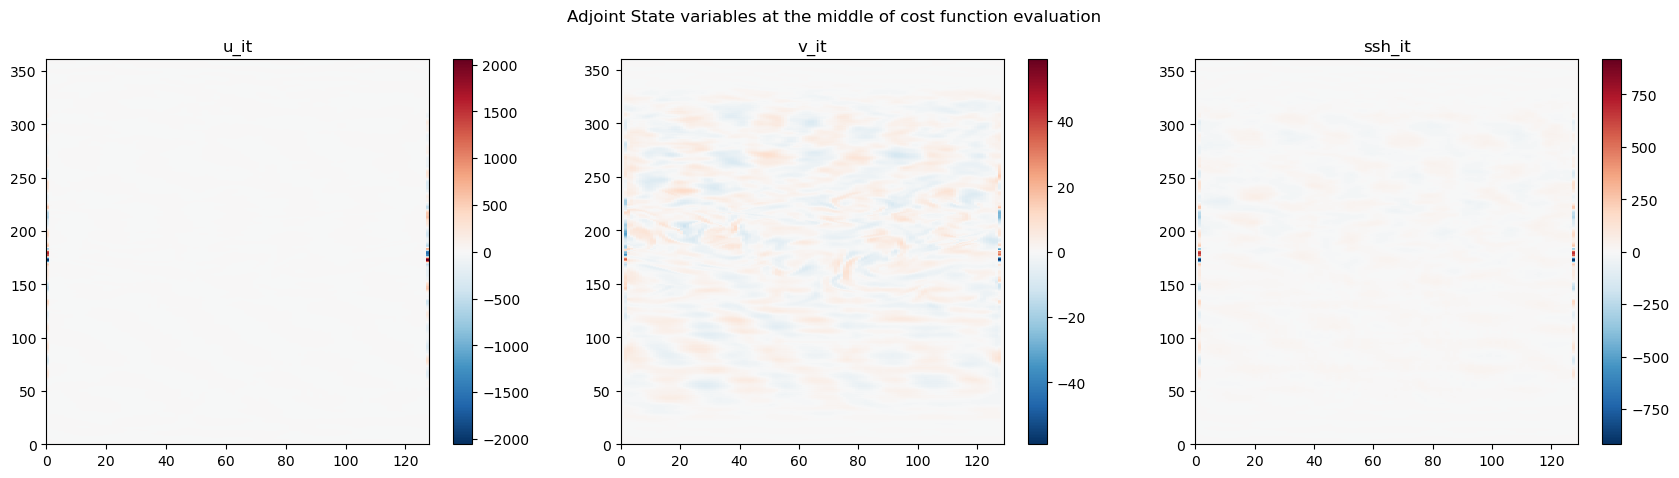

* iteration 30 computed in 1.13E+01 second:, x=-9.88E-02, J=2.63E+04, G=1.56E+01, ftol=2.17E-03, gtol=7.11E-01
* iteration 31 computed in 9.79E+00 second:, x=-9.66E-02, J=2.62E+04, G=7.24E+00, ftol=2.79E-03, gtol=5.37E-01
* iteration 32 computed in 1.00E+01 second:, x=-9.80E-02, J=2.62E+04, G=4.08E+00, ftol=1.59E-03, gtol=4.36E-01
* iteration 33 computed in 8.83E+00 second:, x=-9.84E-02, J=2.61E+04, G=2.68E+00, ftol=1.10E-03, gtol=3.44E-01
* iteration 34 computed in 9.28E+00 second:, x=-9.86E-02, J=2.61E+04, G=3.26E+00, ftol=7.34E-04, gtol=1.79E-01
* iteration 35 computed in 1.03E+01 second:, x=-9.84E-02, J=2.61E+04, G=2.97E+00, ftol=5.33E-04, gtol=8.78E-02
* iteration 36 computed in 9.19E+00 second:, x=-9.79E-02, J=2.61E+04, G=2.12E+00, ftol=4.81E-04, gtol=2.86E-01
* iteration 37 computed in 9.44E+00 second:, x=-9.76E-02, J=2.61E+04, G=1.91E+00, ftol=3.63E-04, gtol=1.01E-01
* iteration 38 computed in 9.63E+00 second:, x=-9.70E-02, J=2.61E+04, G=1.66E+00, ftol=1.27E-04, gtol=1.33E-01
*

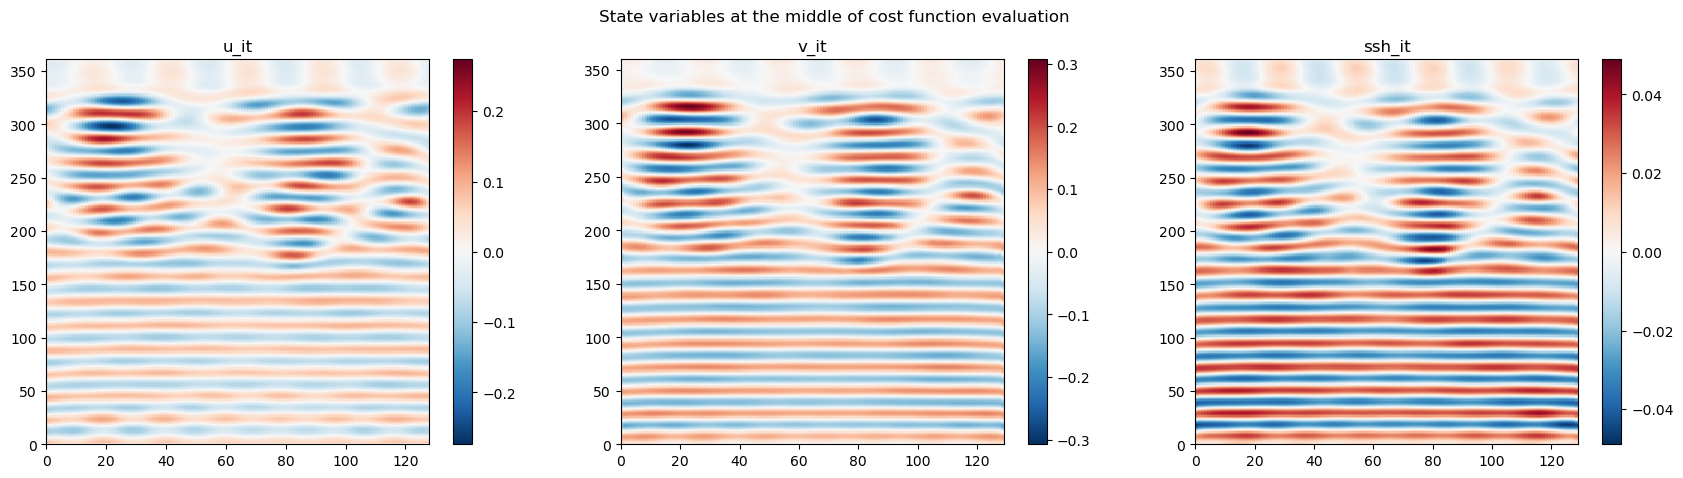

Can't plot parameters
Can't plot parameters


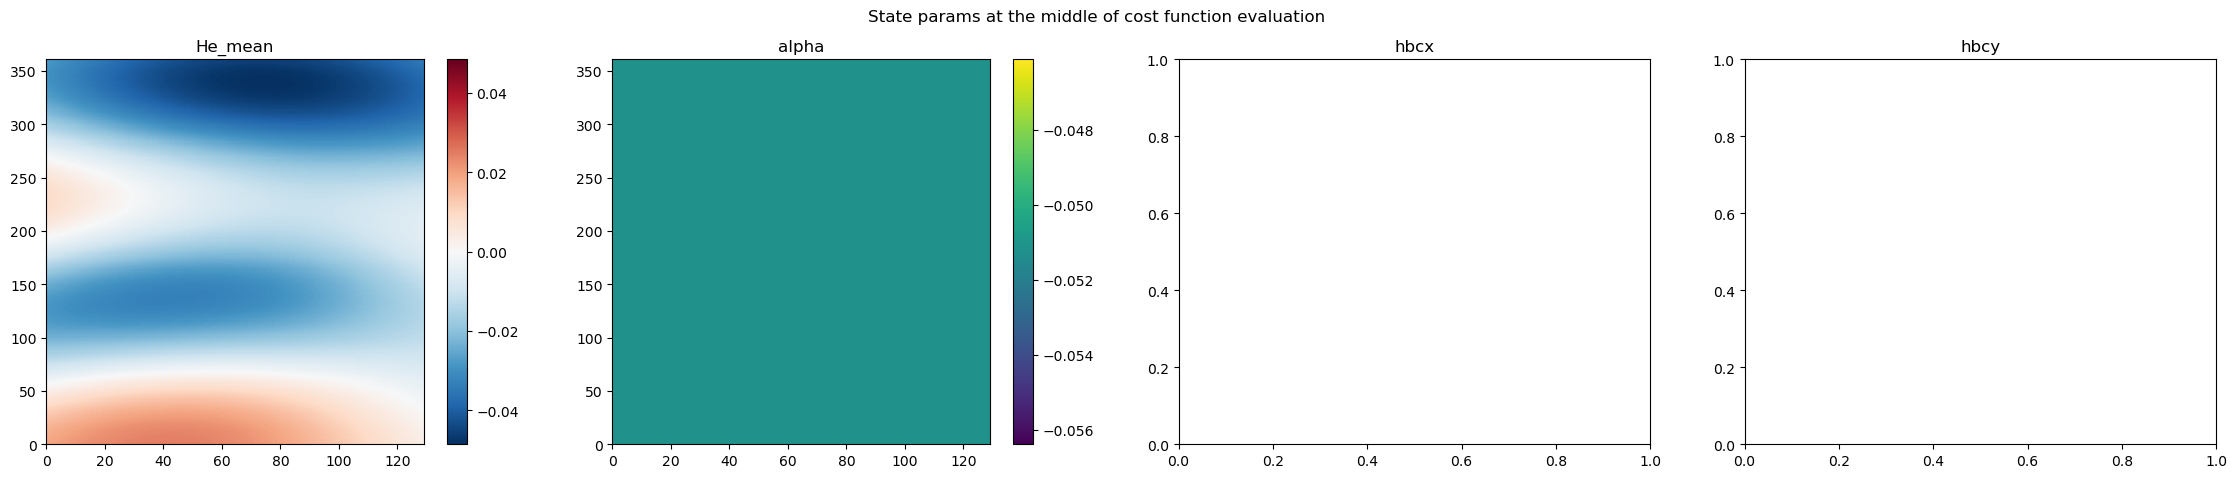

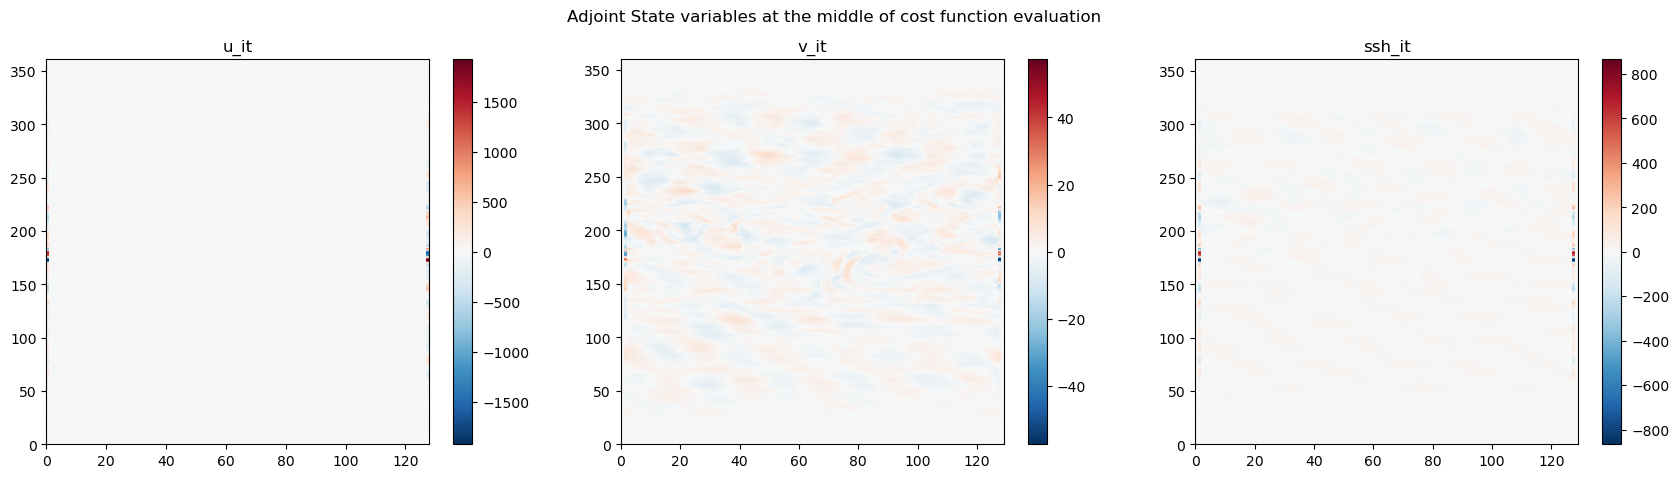

* iteration 40 computed in 1.07E+01 second:, x=-9.39E-02, J=2.61E+04, G=2.06E+00, ftol=5.54E-04, gtol=2.15E-01
* iteration 41 computed in 9.91E+00 second:, x=-9.17E-02, J=2.60E+04, G=1.82E+00, ftol=5.76E-04, gtol=1.14E-01
* iteration 42 computed in 9.87E+00 second:, x=-8.93E-02, J=2.60E+04, G=2.56E+00, ftol=3.93E-04, gtol=2.90E-01
* iteration 43 computed in 8.37E+00 second:, x=-8.83E-02, J=2.60E+04, G=2.53E+00, ftol=3.53E-04, gtol=1.50E-02
* iteration 44 computed in 1.04E+01 second:, x=-8.82E-02, J=2.60E+04, G=1.48E+00, ftol=1.93E-04, gtol=4.12E-01
* iteration 45 computed in 9.65E+00 second:, x=-8.80E-02, J=2.60E+04, G=1.56E+00, ftol=1.43E-04, gtol=4.94E-02
* iteration 46 computed in 9.32E+00 second:, x=-8.68E-02, J=2.60E+04, G=1.90E+00, ftol=4.50E-04, gtol=1.79E-01
* iteration 47 computed in 9.17E+00 second:, x=-8.49E-02, J=2.60E+04, G=6.46E+00, ftol=3.69E-04, gtol=7.05E-01
* iteration 48 computed in 1.02E+01 second:, x=-8.62E-02, J=2.60E+04, G=2.16E+00, ftol=5.36E-04, gtol=6.66E-01
*

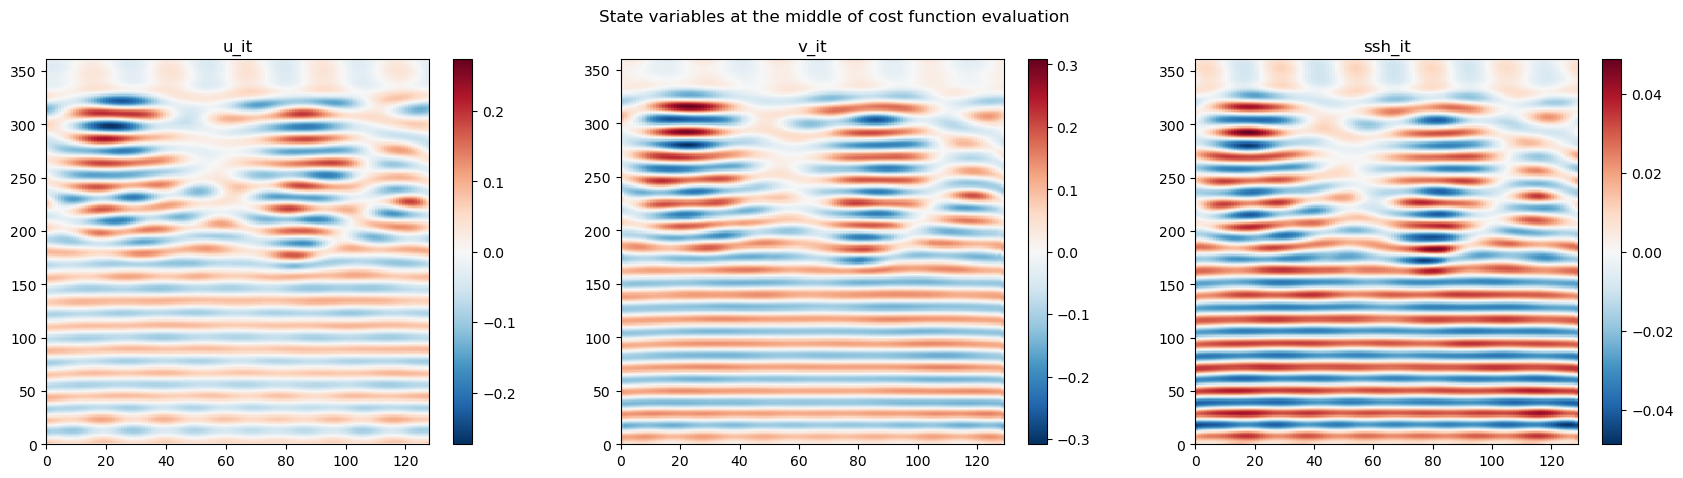

Can't plot parameters
Can't plot parameters


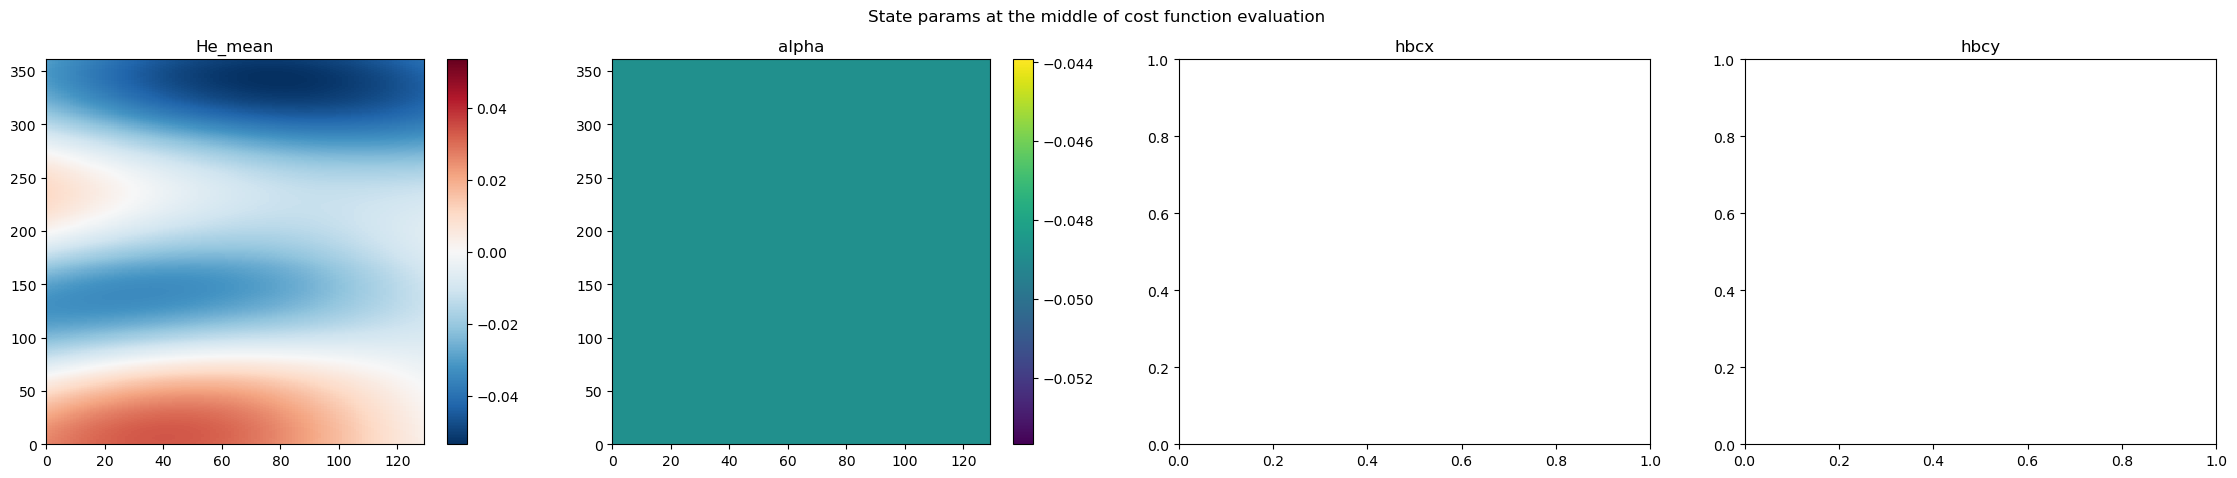

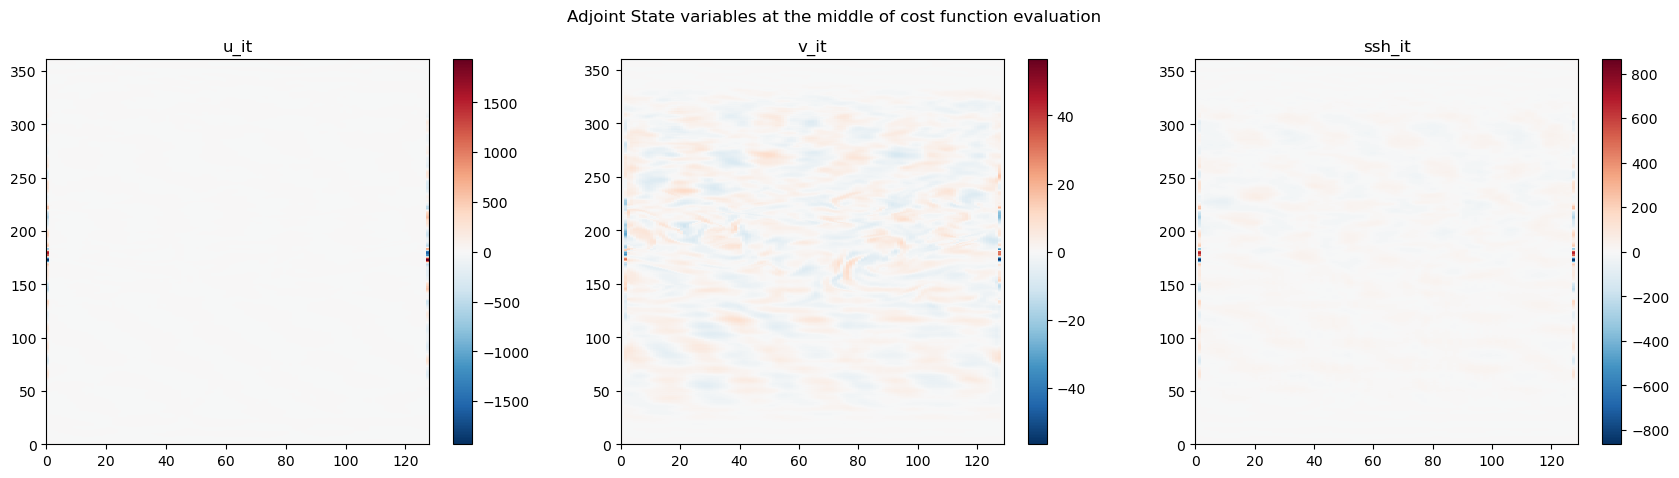

* iteration 50 computed in 1.10E+01 second:, x=-8.39E-02, J=2.60E+04, G=1.50E+00, ftol=2.03E-04, gtol=8.20E-02
* iteration 51 computed in 1.04E+01 second:, x=-8.28E-02, J=2.60E+04, G=2.16E+00, ftol=2.72E-04, gtol=3.04E-01
* iteration 52 computed in 9.13E+00 second:, x=-8.15E-02, J=2.60E+04, G=2.11E+00, ftol=1.66E-04, gtol=2.34E-02
* iteration 53 computed in 9.07E+00 second:, x=-8.18E-02, J=2.60E+04, G=1.31E+00, ftol=1.22E-04, gtol=3.81E-01
* iteration 54 computed in 9.82E+00 second:, x=-8.18E-02, J=2.60E+04, G=1.19E+00, ftol=1.18E-04, gtol=8.79E-02

Is the minimization successful? False

Final cost function value: 25962.268854566817

Number of iterations: 50

*** Saving trajectory ***




In [11]:
from src import inv
inv.Inv(config, State, Model, dict_obs=dict_obs, Obsop=Obsop, Basis=Basis, gpu_device=NUM_GPU)

## Diagnostics

Run the configured OSSE diagnostic after the inversion has written outputs.

super: DIAG_OSSE
dir_output: ./diags/VarDyn-CSWM-JET
time_min: None
time_max: None
time_step: None
lon_min: None
lon_max: None
lat_min: None
lat_max: None
path_images2mp4: /data1/packages/climporn/ffmpeg/images2mp4.sh
name_ref: /data1/data/models/JET_BM-IT/full_resolution/wp6_surf_data_ref_coarse2.nc
name_ref_time: time
name_ref_lon: lon
name_ref_lat: lat
name_ref_var: ssh_it
options_ref: {}
name_exp_time: None
name_exp_lon: None
name_exp_lat: None
name_exp_var: ssh_it
exp_grid_type: None
compare_to_baseline: False
name_bas: None
name_bas_time: time
name_bas_lon: lon
name_bas_lat: lat
name_bas_var: ssh_it
name_mask: None
name_var_mask: {'lon': '', 'lat': '', 'var': ''}



/home/flo/VarDyn/mapping/src/diag.py:145: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self.ref_dims = list(self.ref.dims.keys())


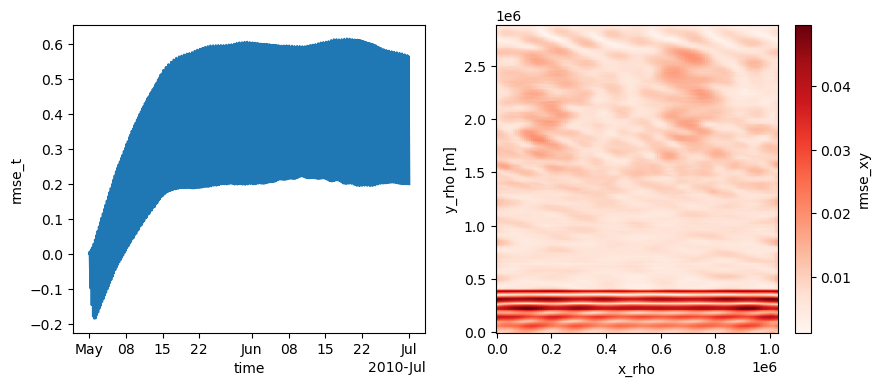

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 185 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 237 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 293 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 353 tasks      | elapsed:  

/data1/packages/climporn/ffmpeg/images2mp4.sh -i ./diags/VarDyn-CSWM-JET/frame -f 24 -D ./diags/VarDyn-CSWM-JET


Input #0, image2, from './diags/VarDyn-CSWM-JET/frame*.png':
  Duration: 00:00:20.33, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: png, rgba(pc), 3600x2000 [SAR 7874:7874 DAR 9:5], 24 fps, 24 tbr, 24 tbn, 24 tbc
Stream mapping:
  Stream #0:0 -> #0:0 (png (native) -> h264 (libx264))
Press [q] to stop, [?] for help
[libx264 @ 0x59ddc40d90c0] using SAR=1/1
[libx264 @ 0x59ddc40d90c0] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2
[libx264 @ 0x59ddc40d90c0] profile High, level 4.2, 4:2:0, 8-bit
[libx264 @ 0x59ddc40d90c0] 264 - core 161 r3030M 8bd6d28 - H.264/MPEG-4 AVC codec - Copyleft 2003-2020 - http://www.videolan.org/x264.html - options: cabac=1 ref=3 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=7 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=34 lookahead_threads=5 sliced_threads=0 nr=0 decimate=1 interlaced=0 bluray_compat=0 constrained_intra=0 bframes=0 weightp


✅ DONE
 → ./diags/VarDyn-CSWM-JET/movie_frame_1080px_24fps_loopx1.mp4
Insert into PowerPoint WITHOUT enabling looping.



[mp4 @ 0x59ddc40d7ec0] Starting second pass: moving the moov atom to the beginning of the file
frame=  488 fps= 13 q=-1.0 Lsize=    9366kB time=00:00:20.29 bitrate=3781.3kbits/s speed=0.555x    
video:9364kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.031215%
[libx264 @ 0x59ddc40d90c0] frame I:21    Avg QP:15.69  size: 86066
[libx264 @ 0x59ddc40d90c0] frame P:467   Avg QP:23.41  size: 16660
[libx264 @ 0x59ddc40d90c0] mb I  I16..4: 31.1% 54.8% 14.1%
[libx264 @ 0x59ddc40d90c0] mb P  I16..4:  3.5%  4.8%  1.3%  P16..4:  5.7%  6.1%  2.2%  0.0%  0.0%    skip:76.5%
[libx264 @ 0x59ddc40d90c0] 8x8 transform intra:51.4% inter:86.5%
[libx264 @ 0x59ddc40d90c0] coded y,uvDC,uvAC intra: 46.4% 68.7% 47.6% inter: 8.6% 8.8% 1.9%
[libx264 @ 0x59ddc40d90c0] i16 v,h,dc,p: 22% 76%  2%  1%
[libx264 @ 0x59ddc40d90c0] i8 v,h,dc,ddl,ddr,vr,hd,vl,hu: 19% 57% 11%  1%  1%  1%  5%  1%  4%
[libx264 @ 0x59ddc40d90c0] i4 v,h,dc,ddl,ddr,vr,hd,vl,hu: 20% 69%  4%  1%  1%  1%  2%  1%  1

In [12]:
from src import diag
Diag = diag.Diag(config, State)
Diag.regrid_exp()
Diag.rmse_based_scores(plot=True)
Diag.movie()